In [70]:
import numpy as np
import matplotlib.pyplot as plt

import h5py
from scipy.signal import welch

In [40]:
import scipy.io as sio
mat_data = sio.loadmat(r"D:\power_monitor\20251007_power_monitor\2025100_g_dc.mat")
dt = mat_data['Tinterval']
gg_dc = mat_data['G'].T[0]

mat_data = sio.loadmat(r"D:\power_monitor\20251007_power_monitor\2025100_g_ac.mat")
gg_ac = mat_data['G'].T[0]

In [54]:
v_mean = np.mean(gg_dc)
ff, dd = welch(gg_ac/v_mean, fs=2000000, nperseg=2**15)

Text(0, 0.5, 'RIN (dB/Hz)')

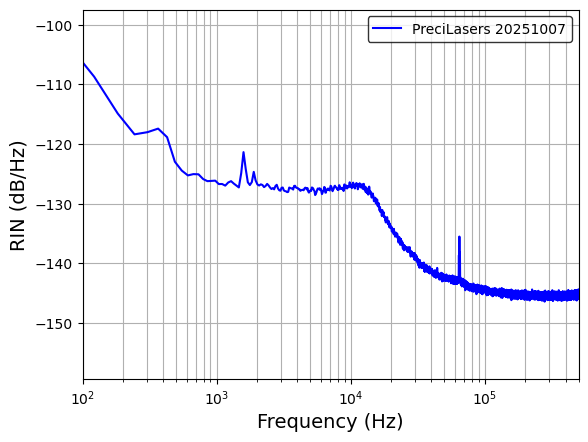

In [69]:
plt.plot(ff, 10*np.log10(dd), 'b', label='PreciLasers 20251007')

plt.xlim(1e2, 500000)
plt.xscale('log')
plt.grid(which='both')

plt.legend(edgecolor='k')
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('RIN (dB/Hz)', fontsize=14)

In [140]:
file_name = rf"D:\accelerometer\20250805_accelerometer_onfloor_gain_1000V_g\20250805_a_0.hdf5"
f = h5py.File(file_name, 'r')

aa = f['data']['channel_a'][:] * f['data']['channel_a'].attrs['adc2mv']/1000
dt = f['data'].attrs['delta_t']

f.close()

aa_g = aa / 1000
ff, pp = welch(aa_g, fs=int(1/dt), nperseg=2**15)

In [141]:
file_name = rf"D:\accelerometer\20251013_accelerometer_ontable_gain_1000V_g\20251013_a_0.hdf5"
f = h5py.File(file_name, 'r')

aa = f['data']['channel_a'][:] * f['data']['channel_a'].attrs['adc2mv']/1000
dt = f['data'].attrs['delta_t']

f.close()

aa_g = aa / 1000
ff_t, pp_t = welch(aa_g, fs=int(1/dt), nperseg=2**15)

(1.0, 500.0)

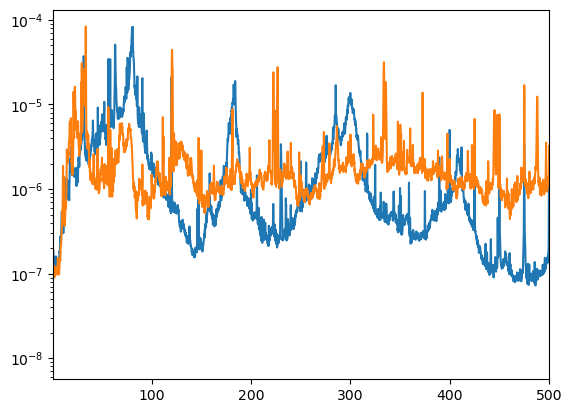

In [142]:
plt.plot(ff, np.sqrt(pp))
plt.plot(ff_t, np.sqrt(pp_t))

# plt.xscale('log')
plt.yscale('log')

plt.xlim(1, 500)